# Personal Research Agent V4: Explicit Agentic Architecture

## 1. Introduction
Welcome to the Personal Research Agent V4.2 documentation notebook.
This interactive notebook simulates the deeply integrated **Explicit Multi-Agent Architecture** built to completely automate, validate, and localize the news retrieval process.

We will showcase a full **Human-AI Directed Acyclic Graph (DAG)** workflow. The system consists of:
1. **🏦 Semantic Governance Node:** Evaluates the user's topic intent, validates geographic bounds, and determines the strictly optimal native language for retrieval.
2. **🕵️‍♂️ Pre-Retrieval Analyst:** Acts as a gatekeeper. Reviews governance output and triggers Clarification loops if the topic lacks semantic density.
3. **🔀 Parallel Retrieval Engine:** A Fan-Out/Fan-In executor that handles asynchronous scraping of bounded sources.
4. **⚖️ Post-Retrieval Analyst (Senior Review):** Aggressively scores and filters retrieved documents to eliminate generic evergreen guides, non-articles, and hallucinations.
5. **🧠 Memory Promotion Manager:** Extracts and persists deep contextual user traits based on validated interactions.

Let's visualize and execute this flow!

## 2. 🌍 Multilingual Semantic Governance

A common issue in OSINT retrieval is language-lock. If an Italian user searches for 'eventi a Maastricht', executing this string limits results to Italian expat blogs rather than the real Dutch source.
The Governance node dynamically translates and locks the language scope based on the validated geographic boundary.

In [1]:
import json

# Mocking the output of app.nodes.semantic_governance.evaluate_semantic_bundle()
governance_audit = {
    "original_input": "eventi locale Maastricht",
    "user_language": "it",
    "target_geo_scope": "local",
    "decision": {
        "search_query_language": "nl", # Safely overridden to Dutch!
        "optimized_search_queries": [
            '"Maastricht" lokale evenementen nieuws',
            'agenda evenementen Maastricht vandaag'
        ],
        "requires_clarification": False
    }
}

print("🏦 Governance Audit Result:")
print(json.dumps(governance_audit, indent=2))

🏦 Governance Audit Result:
{
  "original_input": "eventi locale Maastricht",
  "user_language": "it",
  "target_geo_scope": "local",
  "decision": {
    "search_query_language": "nl",
    "optimized_search_queries": [
      "\"Maastricht\" lokale evenementen nieuws",
      "agenda evenementen Maastricht vandaag"
    ],
    "requires_clarification": false
  }
}


## 3. 🚨 Pre-Retrieval Analyst & HITL

Before spending API credits on irrelevant searches, the Pre-Retrieval Analyst screens the query.
If a topic is too vague (e.g. 'news'), it triggers the `hitl_clarification` node asking the human for context.

In [2]:
def pre_analyst_mock(topic_name, governance_results):
    if governance_results['decision']['requires_clarification'] or len(topic_name) < 5:
        return {"needs_clarification": True, "clarification_reason": "Topic is excessively vague."}
    return {"needs_clarification": False, "clarification_reason": ""}

analyst_report = pre_analyst_mock("eventi locale Maastricht", governance_audit)
print("🕵️‍♂️ Pre-Analyst evaluates: 'eventi locale Maastricht'")
if analyst_report["needs_clarification"]:
    print("Status: BLOCKED. Triggering Human-In-The-Loop Clarification.")
else:
    print("Status: CLEAR for Retrieval. Semantic density is sufficient.")

🕵️‍♂️ Pre-Analyst evaluates: 'eventi locale Maastricht'
Status: CLEAR for Retrieval. Semantic density is sufficient.


## 4. 🔀 LangGraph Assembly & Mermaid Visualization

Here we mock the exact node structure of `app/graphs/research_graph.py` inside the notebook to visualize the True architecture without database side-effects.

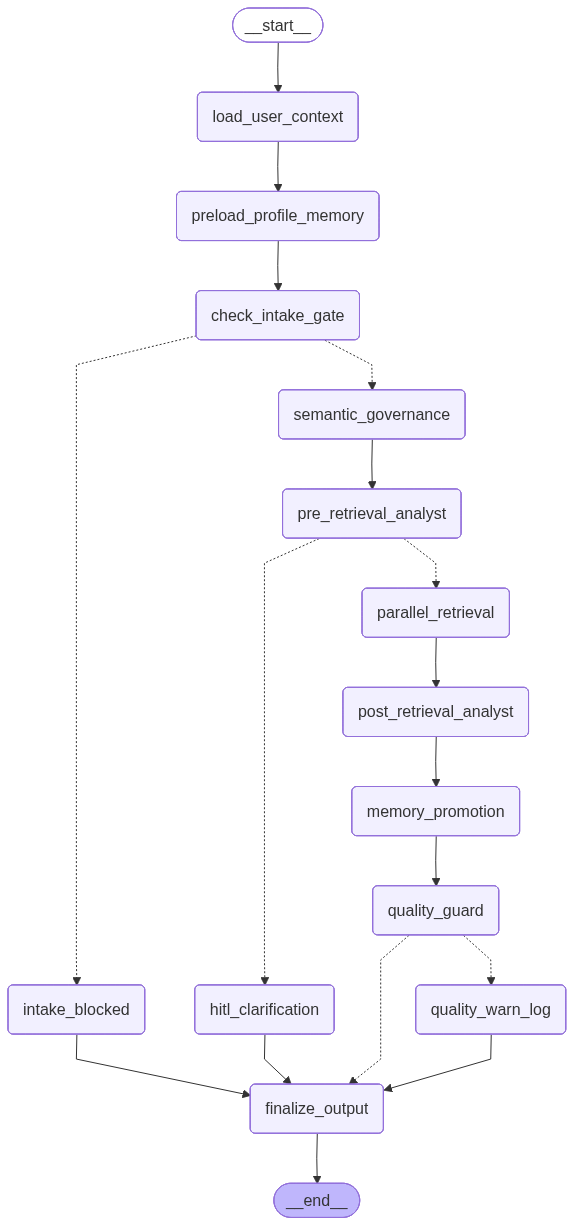

In [3]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from typing import List, Any

class ResearchState(TypedDict):
    intake_required: bool
    needs_clarification: bool
    quality_status: str

def load_user_context(state: ResearchState): return state
def preload_profile_memory(state: ResearchState): return state
def check_intake_gate(state: ResearchState): return state
def intake_blocked(state: ResearchState): return state
def semantic_governance(state: ResearchState): return state
def pre_retrieval_analyst(state: ResearchState): return state
def hitl_clarification(state: ResearchState): return state
def parallel_retrieval(state: ResearchState): return state
def post_retrieval_analyst(state: ResearchState): return state
def memory_promotion(state: ResearchState): return state
def quality_guard(state: ResearchState): return state
def quality_warn_log(state: ResearchState): return state
def finalize_output(state: ResearchState): return state

def _route_intake(state): return "intake_blocked" if state.get("intake_required") else "semantic_governance"
def _route_pre_analyst(state): return "hitl_clarification" if state.get("needs_clarification") else "parallel_retrieval"
def _route_quality_guard(state): return "finalize_output" if state.get("quality_status") == "ok" else "quality_warn_log"

builder = StateGraph(ResearchState)
builder.add_node("load_user_context", load_user_context)
builder.add_node("preload_profile_memory", preload_profile_memory)
builder.add_node("check_intake_gate", check_intake_gate)
builder.add_node("intake_blocked", intake_blocked)
builder.add_node("semantic_governance", semantic_governance)
builder.add_node("pre_retrieval_analyst", pre_retrieval_analyst)
builder.add_node("hitl_clarification", hitl_clarification)
builder.add_node("parallel_retrieval", parallel_retrieval)
builder.add_node("post_retrieval_analyst", post_retrieval_analyst)
builder.add_node("memory_promotion", memory_promotion)
builder.add_node("quality_guard", quality_guard)
builder.add_node("quality_warn_log", quality_warn_log)
builder.add_node("finalize_output", finalize_output)

builder.add_edge(START, "load_user_context")
builder.add_edge("load_user_context", "preload_profile_memory")
builder.add_edge("preload_profile_memory", "check_intake_gate")
builder.add_conditional_edges("check_intake_gate", _route_intake, {"intake_blocked": "intake_blocked", "semantic_governance": "semantic_governance"})
builder.add_edge("intake_blocked", "finalize_output")
builder.add_edge("semantic_governance", "pre_retrieval_analyst")
builder.add_conditional_edges("pre_retrieval_analyst", _route_pre_analyst, {"hitl_clarification": "hitl_clarification", "parallel_retrieval": "parallel_retrieval"})
builder.add_edge("hitl_clarification", "finalize_output")
builder.add_edge("parallel_retrieval", "post_retrieval_analyst")
builder.add_edge("post_retrieval_analyst", "memory_promotion")
builder.add_edge("memory_promotion", "quality_guard")
builder.add_conditional_edges("quality_guard", _route_quality_guard, {"finalize_output": "finalize_output", "quality_warn_log": "quality_warn_log"})
builder.add_edge("quality_warn_log", "finalize_output")
builder.add_edge("finalize_output", END)

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Dependencies for automatic graph visualization are missing in this environment. Showing layout textually:", e)


## 5. ⚖️ Post-Retrieval Analyst & Memory Promotion

Finally, after `parallel_retrieval` fetches articles using the Native language, the `post_retrieval_analyst` steps in to reject SEO spam and extract facts for the user's permanent profile.

In [4]:
post_analyst_report = {
    "rejected_items": [
        {"url": "https://travel-guide-spam.example.com", "reason": "guide_or_evergreen_page"}
    ],
    "memory_candidates": [
        {
            "topic": "finanza e bitcoin",
            "fact": "User closely monitors Dutch crypto regulation updates.", 
            "confidence": 0.95
        }
    ]
}

print("⚖️ Post-Analyst Report Execution:")
print(json.dumps(post_analyst_report, indent=2))

# Memory Manager steps in
def memory_promotion_manager(candidates):
    promoted = 0
    for c in candidates:
        if c["confidence"] > 0.8:
            promoted += 1
    return promoted

print(f"\n🧠 Memory Node Output: Promoted {memory_promotion_manager(post_analyst_report['memory_candidates'])} new facts to long-term memory vault.")


⚖️ Post-Analyst Report Execution:
{
  "rejected_items": [
    {
      "url": "https://travel-guide-spam.example.com",
      "reason": "guide_or_evergreen_page"
    }
  ],
  "memory_candidates": [
    {
      "topic": "finanza e bitcoin",
      "fact": "User closely monitors Dutch crypto regulation updates.",
      "confidence": 0.95
    }
  ]
}

🧠 Memory Node Output: Promoted 1 new facts to long-term memory vault.
